<font face="Times New Roman" size=5>
<div dir=rtl align="center">
<font face="Times New Roman" size=5>
In The Name of God
</font>
<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Electrical Engineering
</font>
<br>
<font color="#008080" size=6>
Communication Systems
</font>
<br>
<font color="#800080" size=5>
project
<br>
</font>
<font size=5>
Hamed Batani 402101339
<br>
</font>
<font size=4>
Fall 2025
<br>
</font>


<br>
</font>



Q2 , 2.1:

In [1]:
import math
from typing import Dict, Iterable, Tuple, Union

Number = Union[int, float]

def entropy_rate(symbol_prob: Union[Dict[str, Number], Iterable[Number]], #here we define function , its input and numerical tolerance
                 tol: float = 1e-12) -> float:
#here we take care of input , turning it all into a probability vector ( what we can work with )
    if isinstance(symbol_prob, dict):
        probs = [float(p) for p in symbol_prob.values()]
    else:
        probs = [float(p) for p in symbol_prob]
# here we take care of diffrent type of unvalid inputs ( in case another table was to test , of course "table1" is correct )
    if not probs:
        raise ValueError("empty probability set. try again!")

    for p in probs:
        if p < 0:
            raise ValueError("Probabilities must be nonnegative.")
        if p > 0 and not math.isfinite(p):
            raise ValueError("probabilities must be finite.")

    s = sum(probs)
    if abs(s - 1.0) > 1e-9:
        probs = [p / s for p in probs]

    H = 0.0
    for p in probs:
        if p > tol:
            H -= p * math.log2(p)
    return H


def main() -> None:
    table1 = {
        "A": 0.25,
        "B": 0.20,
        "C": 0.15,
        "D": 0.10,
        "E": 0.08,
        "F": 0.07,
        "G": 0.05,
        "H": 0.04,
        "I": 0.04,
        "J": 0.02,
    }

    H_theory = entropy_rate(table1)
    H_code = entropy_rate(list(table1.values()))

    print(f"theoretical H(X) from table 1 = {H_theory:.6f} bits/symbol")
    print(f"computed H(X) (probability list) = {H_code:.6f} bits/symbol")
    print(f"absolute difference = {abs(H_theory - H_code):.3e}")


if __name__ == "__main__":
    main()


theoretical H(X) from table 1 = 2.967669 bits/symbol
computed H(X) (probability list) = 2.967669 bits/symbol
absolute difference = 0.000e+00


2.2 :

In [10]:
import math
import random
import heapq
import itertools


# entropy rate of the source , so we basically compute H
def entropy_rate(symbol_probs):
    return -sum(p * math.log(p, 2) for p in symbol_probs.values() if p > 0.0)


# requirement 1: naive length
def naive_fixed_length_avg(symbol_probs, bits_per_symbol=4):
    return float(bits_per_symbol)


# requirement 3: huffman code construction and average length
def huffman_code(symbol_probs):
    heap = []
    counter = itertools.count()

    for sym, p in symbol_probs.items():
        heap.append((p, next(counter), sym))

    heapq.heapify(heap)

    while len(heap) > 1:
        p1, _, n1 = heapq.heappop(heap)
        p2, _, n2 = heapq.heappop(heap)
        heapq.heappush(heap, (p1 + p2, next(counter), (n1, n2)))

    (_, _, root) = heap[0]
    codes = {}

    def walk(node, prefix):
        if isinstance(node, str):
            codes[node] = prefix or "0"
            return
        left, right = node
        walk(left, prefix + "0")
        walk(right, prefix + "1")

    walk(root, "")
    return codes


def average_code_length(symbol_probs, codebook):
    return sum(symbol_probs[sym] * len(codebook[sym]) for sym in symbol_probs)


# requirement 4: source_coder + decoder for correctness check
def source_coder(message, codebook):
    return "".join(codebook[ch] for ch in message)


def _build_prefix_tree(codebook):
    root = {}
    for sym, bits in codebook.items():
        node = root
        for b in bits:
            node = node.setdefault(b, {})
        node["sym"] = sym
    return root


def source_decoder(bitstream, codebook):
    root = _build_prefix_tree(codebook)
    out = []
    node = root

    for b in bitstream:
        if b not in node:
            raise ValueError("invalid bitstream for this codebook")
        node = node[b]
        if "sym" in node:
            out.append(node["sym"])
            node = root

    if node is not root:
        raise ValueError("bitstream ended mid-codeword")

    return "".join(out)


# requirement 5: generate_data according to table 1 distribution
def generate_data(symbol_probs, length, seed=None):
    if seed is not None:
        random.seed(seed)

    syms = list(symbol_probs.keys())
    weights = [symbol_probs[s] for s in syms]
    picks = random.choices(syms, weights=weights, k=length)
    return "".join(picks)



def main():
    symbol_probs = {
        "A": 0.25,
        "B": 0.20,
        "C": 0.15,
        "D": 0.10,
        "E": 0.08,
        "F": 0.07,
        "G": 0.05,
        "H": 0.04,
        "I": 0.04,
        "J": 0.02,
    }



    h = entropy_rate(symbol_probs)
    l_naive = naive_fixed_length_avg(symbol_probs, bits_per_symbol=4)

    codebook = huffman_code(symbol_probs)
    l_huff = average_code_length(symbol_probs, codebook)

    print("entropy rate (bits/symbol):", h)
    print("naive avg length (bits/symbol):", l_naive)
    print("huffman avg length (bits/symbol):", l_huff)
    print("redundancy naive (l-h):", l_naive - h)
    print("redundancy huffman (l-h):", l_huff - h)

    print("huffman codebook:")
    for sym in sorted(codebook.keys()):
        print(sym, codebook[sym])

    msg = generate_data(symbol_probs, length=100, seed=1)
    bits = source_coder(msg, codebook)
    msg_hat = source_decoder(bits, codebook)

    print("generated message:", msg)
    print("encoded bitstream:", bits)
    print("decode ok:", msg_hat == msg)


if __name__ == "__main__":
    main()




entropy rate (bits/symbol): 2.9676688752351565
naive avg length (bits/symbol): 4.0
huffman avg length (bits/symbol): 3.0
redundancy naive (l-h): 1.0323311247648435
redundancy huffman (l-h): 0.032331124764843455
huffman codebook:
A 10
B 00
C 110
D 010
E 1110
F 0111
G 11111
H 01101
I 11110
J 01100
generated message: AFEBCBDFAAFBEABEAIHAACHBABAABCAAACBAFCDAJGABEEHBFDBCGFCCAAFBACEDBBCECBCAAEJCBACJECGACICCBCIAFFGEFCCB
encoded bitstream: 1001111110001100001001111010011100111010001110101111001101101011001101001000101000110101010110001001111100101001100111111000111011100110100011101000110111110111110110101001110010110111001000001101110110001101010111001100110001011001100111011011111101101111011011000110111101001110111111111110011111011000
decode ok: True


In [11]:
# extra: compare naive vs huffman on a real sentence


sentence = "hi, this is hamed batani, and i am writing this sentence for my communication systems project "

# build source from the sentenc
symbols = list(sentence)
counts = {}
for s in symbols:
    counts[s] = counts.get(s, 0) + 1

n = len(symbols)
probs = {s: counts[s] / n for s in counts}

# naive

import math

alphabet_size = len(probs)
naive_bits_per_symbol = math.ceil(math.log(alphabet_size, 2))
naive_total_bits = naive_bits_per_symbol * n


# huffman coding

codebook = huffman_code(probs)
huffman_total_bits = sum(counts[s] * len(codebook[s]) for s in counts)


# results

print("alphabet size:", alphabet_size)
print("message length (symbols):", n)

print("naive bits per symbol:", naive_bits_per_symbol)
print("naive total bits:", naive_total_bits)

print("huffman total bits:", huffman_total_bits)
print("compression gain (bits):", naive_total_bits - huffman_total_bits)


alphabet size: 22
message length (symbols): 94
naive bits per symbol: 5
naive total bits: 470
huffman total bits: 379
compression gain (bits): 91


2.3:

In [12]:
from __future__ import annotations

from dataclasses import dataclass

# requirement 1: hamming (7,4) encoder (systematic, even parity)
def hamming_coder(bits: str, *, pad: bool = True) -> str:
    """
   this encodes a bit string using hamming (7,4) with ordering:
    (p1, p2, d1, p3, d2, d3, d4), even parity.
    if pad is true, zero-pad to a multiple of 4.
    """
    b = _sanitize_bits(bits)

    if len(b) % 4 != 0:
        if not pad:
            raise ValueError("input length must be a multiple of 4 when pad=false")
        b = b + "0" * (4 - (len(b) % 4))

    out = []
    for i in range(0, len(b), 4):
        d1, d2, d3, d4 = (int(x) for x in b[i : i + 4])

        # parity sets by index bits (1-based positions): 1,2,4 are parity
        # positions: 1:p1 2:p2 3:d1 4:p3 5:d2 6:d3 7:d4
        p1 = (d1 ^ d2 ^ d4)  # covers positions 1,3,5,7
        p2 = (d1 ^ d3 ^ d4)  # covers positions 2,3,6,7
        p3 = (d2 ^ d3 ^ d4)  # covers positions 4,5,6,7

        out.extend([str(p1), str(p2), str(d1), str(p3), str(d2), str(d3), str(d4)])

    return "".join(out)


# requirement 2: single-bit error correction demo (supports requirement 1 explanation)
@dataclass(frozen=True)
class CorrectionResult:
    corrected: str
    syndrome: int
    flipped_pos_1based: int  # 0 means no flip was needed


def correct_single_error_hamming74(codeword7: str) -> CorrectionResult:
    """
    here we take a 7-bit hamming (7,4) codeword and correct at most one bit error.
    uses even-parity syndrome; returns corrected codeword and flip position.
    """
    c = _sanitize_bits(codeword7)
    if len(c) != 7:
        raise ValueError("codeword must have length 7")

    x = [int(ch) for ch in c]  # x[0] is position 1
    s1 = x[0] ^ x[2] ^ x[4] ^ x[6]  # check parity on {1,3,5,7}
    s2 = x[1] ^ x[2] ^ x[5] ^ x[6]  # check parity on {2,3,6,7}
    s3 = x[3] ^ x[4] ^ x[5] ^ x[6]  # check parity on {4,5,6,7}

    syndrome = s1 + 2 * s2 + 4 * s3  # binary index of the bad position
    flipped = 0
    if syndrome != 0:
        idx = syndrome - 1
        x[idx] ^= 1
        flipped = syndrome

    return CorrectionResult("".join(str(v) for v in x), syndrome, flipped)


# requirement 3: small runnable example (shows correction on one block)
def demo() -> None:
    data = "1011"
    encoded = hamming_coder(data)
    # inject a 1-bit error at position 6 (1-based) of the first 7-bit block
    corrupted = list(encoded)
    flip_pos = 6 - 1
    corrupted[flip_pos] = "1" if corrupted[flip_pos] == "0" else "0"
    corrupted = "".join(corrupted)

    res = correct_single_error_hamming74(corrupted[:7])

    print("data bits:", data)
    print("encoded:", encoded)
    print("corrupted:", corrupted)
    print("syndrome:", res.syndrome)
    print("corrected block:", res.corrected)
    print("flipped position:", res.flipped_pos_1based)


def _sanitize_bits(bits: str) -> str:
    s = bits.strip().replace(" ", "")
    if any(ch not in "01" for ch in s):
        raise ValueError("bits must contain only 0 and 1")
    return s


if __name__ == "__main__":
    demo()


data bits: 1011
encoded: 0110011
corrupted: 0110001
syndrome: 6
corrected block: 0110011
flipped position: 6


2.4)

In [14]:
import numpy as np

# Part 2.4 Channel: LTI filter + attenuation (dB/km)
def channel_lti(signal, h, length_km=1.0, att_db_per_km=0.2, mode="full"):
    y = np.convolve(signal, h, mode=mode)
    A_db = att_db_per_km * float(length_km)
    a = 10 ** (-A_db / 20.0)  # dB -> linear amplitude
    return a * y


# Part 2.5 , noise :
def add_awgn(signal, noise_var, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    sigma = np.sqrt(float(noise_var))

    if np.iscomplexobj(signal):
        nI = sigma / np.sqrt(2) * rng.standard_normal(signal.shape)
        nQ = sigma / np.sqrt(2) * rng.standard_normal(signal.shape)
        noise = nI + 1j * nQ
    else:
        noise = sigma * rng.standard_normal(signal.shape)

    return signal + noise


# Part 2.6 Matched filter
def matched_filter(received, gT, mode="full"):
    gR = np.conjugate(gT[::-1])  # time-reverse (+ conjugate for complex)
    return np.convolve(received, gR, mode=mode)



2.7 FSK:

initilization :

In [6]:
import numpy as np

# PulseShaping
def PulseShaping(bits, pulse_map, fs=1e6, Tb=10e-3):
    """
    bits: ak
    pulse_map: dict {symbol: 1D np.array pulse samples} OR callable(symbol)->pulse
    fs: sampling frequency (Hz)
    Tb: symbol/pulse duration (s)
    returns:
        t: time axis (s)
        y: shaped baseband waveform (samples)
    """
    bits = np.asarray(bits).astype(int)
    Ns = int(round(fs * Tb))
    y = np.zeros(len(bits) * Ns, dtype=complex)

    for k, b in enumerate(bits):
        p = pulse_map(b) if callable(pulse_map) else pulse_map[b]
        p = np.asarray(p)

        # allow user-provided pulses; enforce exact length Ns by pad/trim
        if len(p) < Ns:
            p = np.pad(p, (0, Ns - len(p)))
        elif len(p) > Ns:
            p = p[:Ns]

        y[k * Ns:(k + 1) * Ns] = p

    t = np.arange(len(y)) / fs
    return t, y



# AnalogMod

def AnalogMod(y, fc, fs=1e6):
    """
    y: sampled baseband waveform (real -> I only, complex -> I+jQ)
    fc: carrier frequency (Hz)
    fs: sampling frequency (Hz)

    returns:
        t: time axis (s)
        xc: real passband signal x_c(t)
    """
    y = np.asarray(y)
    t = np.arange(len(y)) / fs

    I = np.real(y)
    Q = np.imag(y)

    # x_c(t) = I(t) cos(2πf_c t) - Q(t) sin(2πf_c t)
    xc = I * np.cos(2 * np.pi * fc * t) - Q * np.sin(2 * np.pi * fc * t)
    return t, xc

# AnalogDemod
def AnalogDemod(xc, fs, BW, fc, num_taps=399):
    """
    xc: received real passband signal x_c(t)
    fs: sampling frequency (Hz)
    BW: channel/baseband bandwidth (Hz) used for LPF design
    fc: carrier frequency (Hz)
    num_taps: FIR LPF length

    returns:
        t: time axis (s)
        yI: demodulated in-phase waveform
        yQ: demodulated quadrature waveform
    """
    xc = np.asarray(xc)
    t = np.arange(len(xc)) / fs

    # Mix down (coherent)
    mixI = 2.0 * xc * np.cos(2 * np.pi * fc * t)
    mixQ = -2.0 * xc * np.sin(2 * np.pi * fc * t)


    cutoff = BW
    cutoff = min(cutoff, 0.499 * fs)  # safety
    n = np.arange(num_taps) - (num_taps - 1) / 2
    h = 2 * cutoff / fs * np.sinc(2 * cutoff * n / fs)
    w = np.hamming(num_taps)
    h = h * w
    h = h / np.sum(h)

    yI = np.convolve(mixI, h, mode="same")
    yQ = np.convolve(mixQ, h, mode="same")
    return t, yI, yQ


a )

In [17]:

L = 8000
SEED = 6

symbol_probs = {
    "A": 0.25,
    "B": 0.20,
    "C": 0.15,
    "D": 0.10,
    "E": 0.08,
    "F": 0.07,
    "G": 0.05,
    "H": 0.04,
    "I": 0.04,
    "J": 0.02,
}

# 1) generate symbols strictly from Table 1
msg = generate_data(symbol_probs, length=L, seed=SEED)

print("Generation rule:")
print("random.seed(SEED)")
print("random.choices(Table1 alphabet, weights, k=L)")
print("L =", L, "SEED =", SEED)
print("first 80 symbols:", msg[:80])

# 2) source coding
codebook = huffman_code(symbol_probs)      # build Huffman code
bits_src = source_coder(msg, codebook)

#  3) HAMMING CHANNEL CODING
bits_ham = hamming_coder(bits_src, pad=True)

print("\nLengths:")
print("symbols:", len(msg))
print("source-coded bits:", len(bits_src))
print("hamming-coded bits:", len(bits_ham))

pad_bits = (4 - (len(bits_src) % 4)) % 4
print("zero padding before Hamming:", pad_bits)



#saving the block
MOD_NAME = "FSK"
saved = globals().get("saved", {})
saved["symbol_probs"] = symbol_probs
saved["L"] = L
saved["SEED"] = SEED
saved["msg"] = msg
saved["bits_src"] = bits_src
saved["bits_ham"] = bits_ham
saved["bitstream_all"] = bits_ham.strip().replace(" ", "")
globals()["saved"] = saved



Generation rule:
random.seed(SEED)
random.choices(Table1 alphabet, weights, k=L)
L = 8000 SEED = 6
first 80 symbols: FFCBADCEBEBFEBCDACFBFDFBAFFBAADBICADBHHCDDFIABDBCAGCADBACAAGDAEABHDBBBAJABEBJAIG

Lengths:
symbols: 8000
source-coded bits: 23955
hamming-coded bits: 41923
zero padding before Hamming: 1


b )

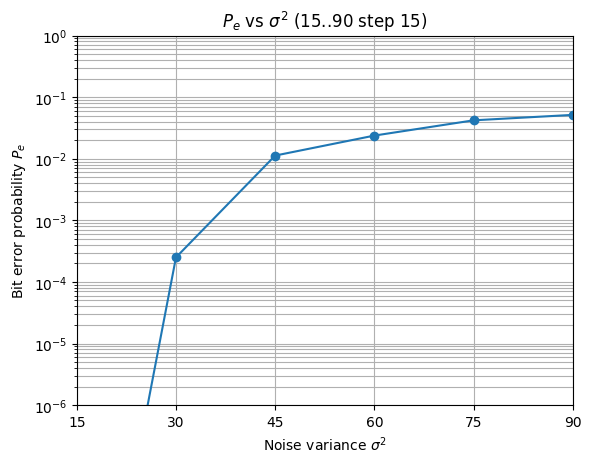

var_list: [15. 30. 45. 60. 75. 90.]
Pe: [0.      0.00025 0.01125 0.02375 0.042   0.0515 ]


In [45]:
import numpy as np
import matplotlib.pyplot as plt

fs = 1e6
Tb = 10e-3
fc = 10e3
Ns = int(round(fs * Tb))

def channel_ideal(x, length_km=0.83, att_db_per_km=0.2):
    gain = 10 ** (-(att_db_per_km * float(length_km)) / 20.0)  # amplitude attenuation
    return gain * np.asarray(x)


N_BITS_SIM=4000

bitstream = bits_ham.strip().replace(" ", "")[:N_BITS_SIM]
if len(bitstream) < 20:
    raise ValueError("bitstream too short")

def bits_to_symbols_2bit(bits01: str):
    if any(c not in "01" for c in bits01):
        raise ValueError("bitstream must contain only 0/1")
    if len(bits01) % 2 != 0:
        bits01 += "0"
    syms = [(int(bits01[i]) << 1) | int(bits01[i+1]) for i in range(0, len(bits01), 2)]
    return np.array(syms, dtype=int), bits01

def symbols_to_bits_2bit(syms):
    out = []
    for s in syms:
        out.append("1" if (s & 2) else "0")
        out.append("1" if (s & 1) else "0")
    return "".join(out)

syms_tx, bits_used = bits_to_symbols_2bit(bitstream)

# 4 orthogonal passband tones (spacing 1/Tb)
t_sym = np.arange(Ns) / fs
freqs = [fc + 1/Tb, fc + 2/Tb, fc + 3/Tb, fc + 4/Tb]

refs = []
for f in freqs:
    ref = np.cos(2*np.pi*f*t_sym)
    ref = ref / np.sqrt(np.sum(ref**2))   # energy normalize
    refs.append(ref)

pulse_map_4 = {m: refs[m] for m in range(4)}

def detect_4fsk_passband(r_c, refs, Ns):
    K = len(r_c) // Ns
    r = r_c[:K*Ns].reshape(K, Ns)
    scores = np.zeros((K, 4))
    for m in range(4):
        scores[:, m] = np.sum(r * refs[m], axis=1)
    return np.argmax(scores, axis=1).astype(int)

# build TX waveform (already passband)
t_tx, s_tx = PulseShaping(syms_tx, pulse_map_4, fs=fs, Tb=Tb)
s_tx = np.real(s_tx)


rng_cal = np.random.default_rng(1)
length_km = 2
sigma2_cal = 45.0

def ber_for_A(A):
    x = channel_ideal(A * s_tx, length_km=length_km, att_db_per_km=0.2)
    r = add_awgn(x, noise_var=sigma2_cal, rng=rng_cal)
    syms_hat = detect_4fsk_passband(r, refs, Ns)
    bits_hat = symbols_to_bits_2bit(syms_hat)

    N = min(len(bits_used), len(bits_hat))
    err = sum(bits_used[i] != bits_hat[i] for i in range(N))
    return err / N
A_candidates = np.logspace(-1, 4, 30)
target = 5e-3

best_A = A_candidates[0]
best_diff = float("inf")
best_ber = None

for A in A_candidates:
    ber = ber_for_A(A)
    diff = abs(np.log10(ber + 1e-12) - np.log10(target))
    if diff < best_diff:
        best_diff = diff
        best_A = A
        best_ber = ber

A = best_A

# now we sweep
var_list = np.arange(15, 91, 15, dtype=float)
Pe = []

rng = np.random.default_rng(0)

for var in var_list:
    x_ch = channel_ideal(A * s_tx, length_km=length_km, att_db_per_km=0.2)
    r_c = add_awgn(x_ch, noise_var=var, rng=rng)

    syms_hat = detect_4fsk_passband(r_c, refs, Ns)
    bits_hat = symbols_to_bits_2bit(syms_hat)

    N = min(len(bits_used), len(bits_hat))
    err = sum(bits_used[i] != bits_hat[i] for i in range(N))
    Pe.append(err / N)

Pe = np.array(Pe)

# plot
Pe_plot = np.where(Pe == 0, 1e-12, Pe)

plt.figure()
plt.semilogy(var_list, Pe_plot, marker="o")
plt.xticks(var_list)
plt.xlabel(r"Noise variance $\sigma^2$")
plt.ylabel(r"Bit error probability $P_e$")
plt.grid(True, which="both")
plt.title(r"$P_e$ vs $\sigma^2$ (15..90 step 15)")

plt.ylim(1e-6, 1)
plt.xlim(15, 90)

plt.show()

print("var_list:", var_list)
print("Pe:", Pe)


#saving the block
MOD_NAME = "FSK"
saved = globals().get("saved", {})
saved.setdefault("BER", {})
saved["BER"].setdefault(MOD_NAME, {})

L = float(length_km)

saved["BER"][MOD_NAME][L] = {
    "A": A,
    "var_list": np.array(var_list, dtype=float),
    "Pe": np.array(Pe, dtype=float),
}

for k in list(saved["BER"][MOD_NAME].keys()):
    if not isinstance(k, float):
        del saved["BER"][MOD_NAME][k]

globals()["saved"] = saved






c )

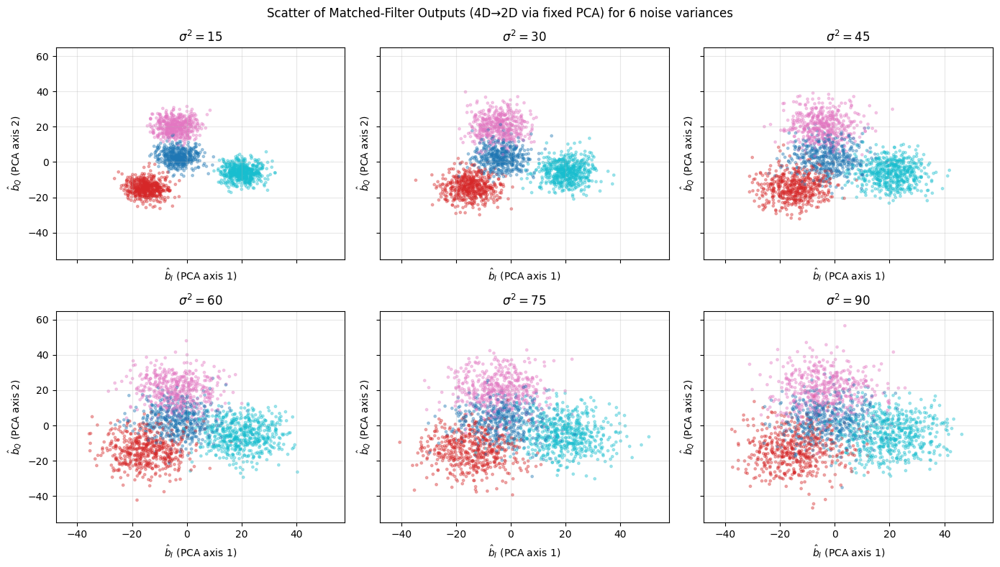

In [19]:
def matched_filter_scores_4fsk_passband(r_c, refs, Ns):
    K = len(r_c) // Ns
    r = r_c[:K*Ns].reshape(K, Ns)
    scores = np.zeros((K, 4))
    for m in range(4):
        scores[:, m] = np.sum(r * refs[m], axis=1)   # matched filter outputs
    return scores  # shape (K,4)

def pca_fit_4to2(X):
    # X: (N,4)
    mu = X.mean(axis=0, keepdims=True)
    Xc = X - mu
    C = (Xc.T @ Xc) / (Xc.shape[0] - 1)  # covariance
    w, V = np.linalg.eigh(C)             # eigen-decomp (ascending)
    idx = np.argsort(w)[::-1]            # sort descending
    W2 = V[:, idx[:2]]                   # top-2 eigenvectors, shape (4,2)
    return mu, W2

def pca_project(X, mu, W2):
    return (X - mu) @ W2  # (N,2)


var_ref = float(var_list[0])
x_ch_ref = channel_ideal(A * s_tx, length_km=length_km, att_db_per_km=0.2)
r_ref = add_awgn(x_ch_ref, noise_var=var_ref, rng=np.random.default_rng(123))
scores_ref = matched_filter_scores_4fsk_passband(r_ref, refs, Ns)

mu_pca, W2_pca = pca_fit_4to2(scores_ref)


proj_all = []
proj_by_var = []
tx_syms_aligned = syms_tx.copy()

for var in var_list:
    x_ch = channel_ideal(A * s_tx, length_km=length_km, att_db_per_km=0.2)
    r_c = add_awgn(x_ch, noise_var=float(var), rng=np.random.default_rng(1000 + int(var)))

    scores = matched_filter_scores_4fsk_passband(r_c, refs, Ns)


    K = scores.shape[0]
    tx_syms = tx_syms_aligned[:K]

    Z = pca_project(scores, mu_pca, W2_pca)  # (K,2)
    proj_by_var.append((var, Z, tx_syms))
    proj_all.append(Z)

proj_all = np.vstack(proj_all)
xmin, ymin = proj_all.min(axis=0)
xmax, ymax = proj_all.max(axis=0)


mx = 0.08 * (xmax - xmin + 1e-12)
my = 0.08 * (ymax - ymin + 1e-12)

# all together
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (var, Z, tx_syms) in zip(axes, proj_by_var):

    ax.scatter(Z[:, 0], Z[:, 1], s=6, alpha=0.35, c=tx_syms, cmap="tab10")
    ax.set_title(rf"$\sigma^2={var:.0f}$")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(xmin - mx, xmax + mx)
    ax.set_ylim(ymin - my, ymax + my)
    ax.set_xlabel(r"$\hat{b}_I$ (PCA axis 1)")
    ax.set_ylabel(r"$\hat{b}_Q$ (PCA axis 2)")

fig.suptitle("Scatter of Matched-Filter Outputs (4D→2D via fixed PCA) for 6 noise variances", y=0.98)
plt.tight_layout()
plt.show()

#saving the block
MOD_NAME = "FSK"
saved = globals().get("saved", {})
saved.setdefault("SCATTER", {})
saved["SCATTER"][MOD_NAME] = proj_by_var
globals()["saved"] = saved


d)

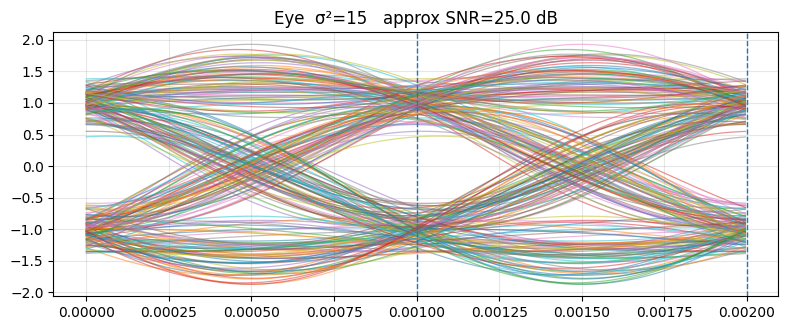

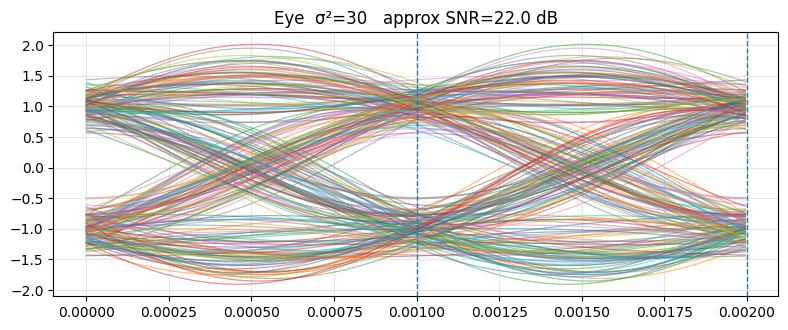

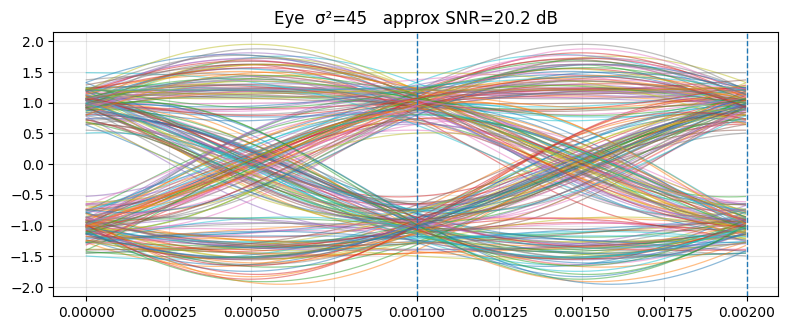

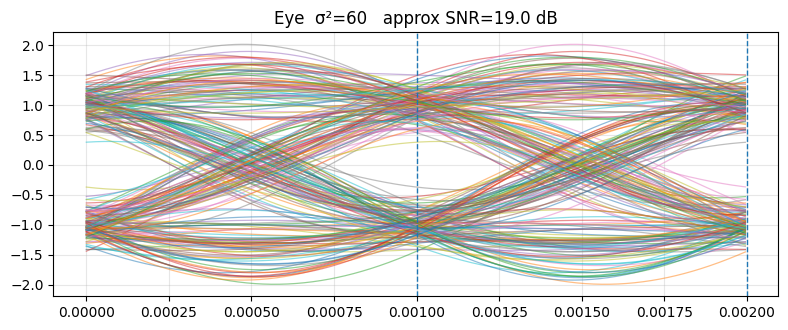

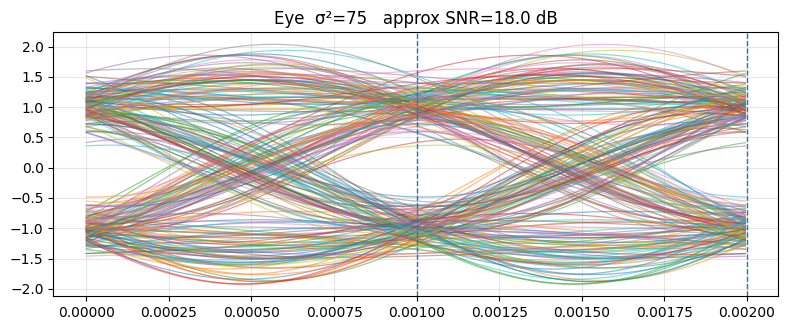

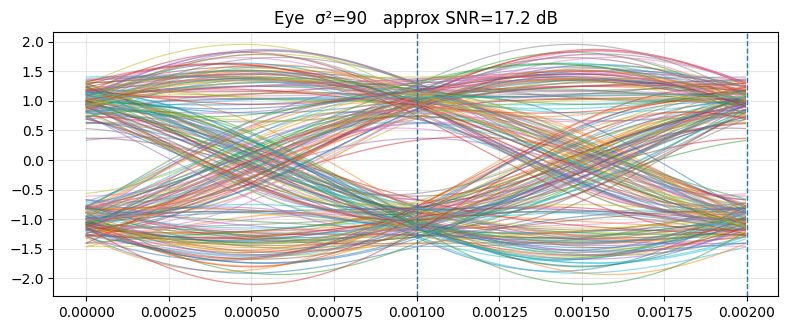

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def raised_cosine_pulse(beta, Tb, fs, span_symbols=8):
    Ts = 1 / fs
    N = int(span_symbols * Tb * fs)
    if N % 2 == 0:
        N += 1
    t = (np.arange(N) - N // 2) * Ts
    p = np.zeros_like(t)

    for i, ti in enumerate(t):
        x = ti / Tb
        if np.isclose(ti, 0.0):
            p[i] = 1.0
        elif beta != 0 and np.isclose(abs(x), 1/(2*beta)):
            p[i] = (np.pi/4) * np.sinc(1/(2*beta))
        else:
            p[i] = np.sinc(x) * np.cos(np.pi*beta*x) / (1-(2*beta*x)**2)

    p /= (np.sqrt(np.sum(p**2)) + 1e-15)
    return p

def synthesize_y(symbols, p, sps):
    up = np.zeros(len(symbols) * sps)
    up[::sps] = symbols
    return np.convolve(up, p, mode="same")

def eye_segments(y, sps, window_symbols=2, max_traces=250, skip_symbols=10, offset=0):
    L = window_symbols * sps
    start = skip_symbols * sps + offset
    end = len(y) - L - skip_symbols * sps
    if end <= start:
        return None
    starts = np.arange(start, end + 1, sps)
    if len(starts) > max_traces:
        starts = starts[:max_traces]
    return np.stack([y[i:i+L] for i in starts], axis=0)

def plot_eye(y, Tb, fs, sps, title, offset=0):
    segs = eye_segments(y, sps, window_symbols=2, max_traces=250, skip_symbols=10, offset=offset)
    if segs is None:
        print("too short")
        return
    t = np.arange(segs.shape[1]) / fs
    plt.figure(figsize=(8, 3.4))
    for s in segs:
        plt.plot(t, s, alpha=0.5, linewidth=0.9)
    plt.axvline(Tb, linestyle="--", linewidth=1.0)
    plt.axvline(2*Tb, linestyle="--", linewidth=1.0)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def main():
    Tb = 1e-3
    fs = 200_000
    sps = int(round(Tb * fs))

    beta = 0.35
    p = raised_cosine_pulse(beta, Tb, fs, span_symbols=10)
    gd = (len(p) - 1) // 2

    Nsym = 600
    symbols = np.random.choice([-1, 1], size=Nsym)
    y_tx = synthesize_y(symbols, p, sps)
    z_tx = np.convolve(y_tx, p[::-1], mode="same")
    Ps = np.mean(z_tx**2)
    sigma2_list = [15, 30, 45, 60, 75, 90]
    sigma2_ref = 15
    SNR_ref_dB = 25
    SNR_ref = 10 ** (SNR_ref_dB / 10)
    k = Ps / (SNR_ref * sigma2_ref)
    np.random.seed(1)

    for sigma2 in sigma2_list:
        noise_var = k * sigma2
        y_rx = y_tx + np.sqrt(noise_var) * np.random.randn(len(y_tx))
        z = np.convolve(y_rx, p[::-1], mode="same")

        snr_lin = Ps / (noise_var + 1e-15)
        snr_db = 10*np.log10(snr_lin + 1e-15)

        plot_eye(
            z,
            Tb,
            fs,
            sps,
            title=f"Eye  σ²={sigma2}   approx SNR={snr_db:.1f} dB",
            offset=gd
        )

if __name__ == "__main__":
    main()

    #save
    MOD_NAME = "FSK"
saved = globals().get("saved", {})
saved.setdefault("EYE", {})
saved["EYE"][MOD_NAME] = {
    "sigma2_list": sigma2_list if "sigma2_list" in globals() else None,
    "Tb": Tb if "Tb" in globals() else None,
    "fs": fs if "fs" in globals() else None,
}
globals()["saved"] = saved



QPSK :

a )

In [21]:

L = 8000
SEED = 6

symbol_probs = {
    "A": 0.25,
    "B": 0.20,
    "C": 0.15,
    "D": 0.10,
    "E": 0.08,
    "F": 0.07,
    "G": 0.05,
    "H": 0.04,
    "I": 0.04,
    "J": 0.02,
}

# 1) generate symbols strictly from Table 1
msg = generate_data(symbol_probs, length=L, seed=SEED)

print("QPSK Part (a) — Generation rule:")
print("random.seed(SEED)")
print("random.choices(Table1 alphabet, weights, k=L)")
print("L =", L, "SEED =", SEED)
print("first 80 symbols:", msg[:80])

# 2) source coding (Huffman)
codebook = huffman_code(symbol_probs)
bits_src = source_coder(msg, codebook)

# 3) channel coding (Hamming 7,4)
bits_ham = hamming_coder(bits_src, pad=True)

print("\nLengths:")
print("symbols:", len(msg))
print("source-coded bits:", len(bits_src))
print("hamming-coded bits:", len(bits_ham))

pad_bits = (4 - (len(bits_src) % 4)) % 4
print("zero padding before Hamming:", pad_bits)

# bits_ham is the final 0/1 bitstream used for QPSK mapping in Part (b)

#saving the block
MOD_NAME = "QPSK"
saved = globals().get("saved", {})
saved["symbol_probs"] = symbol_probs
saved["L"] = L
saved["SEED"] = SEED
saved["msg"] = msg
saved["bits_src"] = bits_src
saved["bits_ham"] = bits_ham
saved["bitstream_all"] = bits_ham.strip().replace(" ", "")
globals()["saved"] = saved


QPSK Part (a) — Generation rule:
random.seed(SEED)
random.choices(Table1 alphabet, weights, k=L)
L = 8000 SEED = 6
first 80 symbols: FFCBADCEBEBFEBCDACFBFDFBAFFBAADBICADBHHCDDFIABDBCAGCADBACAAGDAEABHDBBBAJABEBJAIG

Lengths:
symbols: 8000
source-coded bits: 23955
hamming-coded bits: 41923
zero padding before Hamming: 1


b )

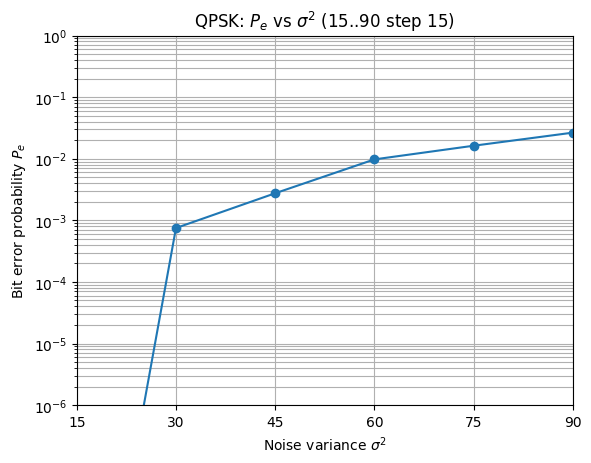

A used: 27.283333764867667 (cal BER ~ 0.0035 )
var_list: [15. 30. 45. 60. 75. 90.]
Pe: [0.      0.00075 0.00275 0.00975 0.01625 0.0265 ]


In [44]:

import numpy as np
import matplotlib.pyplot as plt

fs = 1e6
Tb = 10e-3
fc = 10e3
Ns = int(round(fs * Tb))

N_BITS_SIM = 4000
bitstream = bits_ham.strip().replace(" ", "")[:N_BITS_SIM]
if len(bitstream) < 20:
    raise ValueError("bitstream too short")


def bits_to_symbols_2bit(bits01: str):
    if any(c not in "01" for c in bits01):
        raise ValueError("bitstream must contain only 0/1")
    if len(bits01) % 2 != 0:
        bits01 += "0"
    syms = [(int(bits01[i]) << 1) | int(bits01[i + 1]) for i in range(0, len(bits01), 2)]
    return np.array(syms, dtype=int), bits01


def symbols_to_bits_2bit(syms):
    out = []
    for s in syms:
        out.append("1" if (s & 2) else "0")
        out.append("1" if (s & 1) else "0")
    return "".join(out)


syms_tx, bits_used = bits_to_symbols_2bit(bitstream)

# now we must build 4 orthonormal passband references (QPSK)
t_sym = np.arange(Ns) / fs
c = np.cos(2 * np.pi * fc * t_sym)
s = np.sin(2 * np.pi * fc * t_sym)

IQ = {
    0: (+1.0, +1.0),
    1: (-1.0, +1.0),
    2: (+1.0, -1.0),
    3: (-1.0, -1.0),
}

refs = []
for m in range(4):
    I, Q = IQ[m]
    ref = I * c - Q * s
    ref = ref / np.sqrt(np.sum(ref ** 2))  # energy normalize (like your FSK)
    refs.append(ref)

pulse_map_qpsk = {m: refs[m] for m in range(4)}


def detect_bank_passband(r_c, refs, Ns):
    K = len(r_c) // Ns
    r = r_c[:K * Ns].reshape(K, Ns)
    scores = np.zeros((K, len(refs)))
    for m in range(len(refs)):
        scores[:, m] = np.sum(r * refs[m], axis=1)
    return np.argmax(scores, axis=1).astype(int)


# --- build TX waveform (already passband) ---
t_tx, s_tx = PulseShaping(syms_tx, pulse_map_qpsk, fs=fs, Tb=Tb)
s_tx = np.real(s_tx)

# --- amplitude calibration: make sure A selection is stable ---
length_km = 2
sigma2_cal = 45.0


def ber_for_A(A):
    # reset RNG each time to make A-search deterministic
    rng_cal = np.random.default_rng(1)
    x = channel_ideal(A * s_tx, length_km=length_km, att_db_per_km=0.2)
    r = add_awgn(x, noise_var=sigma2_cal, rng=rng_cal)
    syms_hat = detect_bank_passband(r, refs, Ns)
    bits_hat = symbols_to_bits_2bit(syms_hat)

    N = min(len(bits_used), len(bits_hat))
    err = sum(bits_used[i] != bits_hat[i] for i in range(N))
    return err / N


A_candidates = np.logspace(-1, 4, 40)
target = 5e-3

best_A = A_candidates[0]
best_diff = float("inf")
best_ber = None

for A_try in A_candidates:
    ber = ber_for_A(A_try)
    diff = abs(np.log10(ber + 1e-12) - np.log10(target))
    if diff < best_diff:
        best_diff = diff
        best_A = A_try
        best_ber = ber

A = best_A

#  sweep noise variances
var_list = np.arange(15, 91, 15, dtype=float)
Pe = []

rng = np.random.default_rng(0)

for var in var_list:
    x_ch = channel_ideal(A * s_tx, length_km=length_km, att_db_per_km=0.2)
    r_c = add_awgn(x_ch, noise_var=var, rng=rng)

    syms_hat = detect_bank_passband(r_c, refs, Ns)
    bits_hat = symbols_to_bits_2bit(syms_hat)

    N = min(len(bits_used), len(bits_hat))
    err = sum(bits_used[i] != bits_hat[i] for i in range(N))
    Pe.append(err / N)

Pe = np.array(Pe)
Pe_plot = np.where(Pe == 0, 1e-12, Pe)

plt.figure()
plt.semilogy(var_list, Pe_plot, marker="o")
plt.xticks(var_list)
plt.xlabel(r"Noise variance $\sigma^2$")
plt.ylabel(r"Bit error probability $P_e$")
plt.grid(True, which="both")
plt.title(r"QPSK: $P_e$ vs $\sigma^2$ (15..90 step 15)")
plt.ylim(1e-6, 1)
plt.xlim(15, 90)
plt.show()

print("var_list:", var_list)
print("Pe:", Pe)

#saving the block
MOD_NAME = "QPSK"
saved = globals().get("saved", {})
saved.setdefault("BER", {})
saved["BER"].setdefault(MOD_NAME, {})

L = float(length_km)

saved["BER"][MOD_NAME][L] = {
    "A": A,
    "var_list": np.array(var_list, dtype=float),
    "Pe": np.array(Pe, dtype=float),
}

for k in list(saved["BER"][MOD_NAME].keys()):
    if not isinstance(k, float):
        del saved["BER"][MOD_NAME][k]

globals()["saved"] = saved





c )

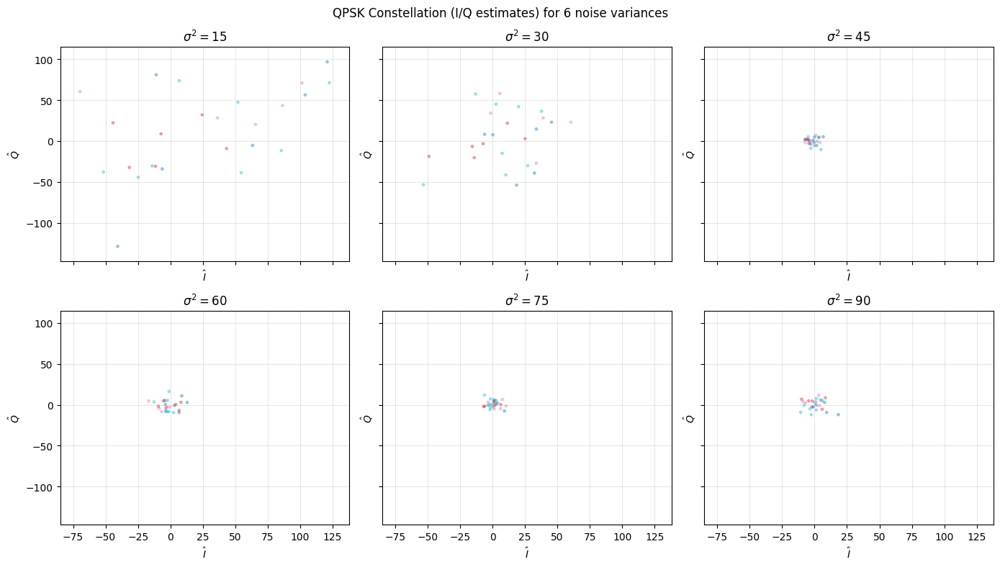

In [30]:

import numpy as np
import matplotlib.pyplot as plt


def bits_to_symbols_2bit(bits01: str):
    if any(c not in "01" for c in bits01):
        raise ValueError("bitstream must contain only 0/1")
    if len(bits01) % 2 != 0:
        bits01 += "0"
    syms = [(int(bits01[i]) << 1) | int(bits01[i + 1]) for i in range(0, len(bits01), 2)]
    return np.array(syms, dtype=int), bits01


bitstream_q = bits_ham.strip().replace(" ", "")[:N_BITS_SIM]
syms_tx_q, bits_used_q = bits_to_symbols_2bit(bitstream_q)

t_sym = np.arange(Ns) / fs
c = np.cos(2 * np.pi * fc * t_sym)
s = np.sin(2 * np.pi * fc * t_sym)
c0 = c / np.sqrt(np.sum(c ** 2))
s0 = s / np.sqrt(np.sum(s ** 2))

IQ = {
    0: (+1.0, +1.0),  # 00
    1: (-1.0, +1.0),  # 01
    2: (+1.0, -1.0),  # 10
    3: (-1.0, -1.0),  # 11
}

I_seq = np.array([IQ[int(m)][0] for m in syms_tx_q], dtype=float)
Q_seq = np.array([IQ[int(m)][1] for m in syms_tx_q], dtype=float)

refs = []
for m in range(4):
    I, Q = IQ[m]
    refs.append(I * c - Q * s)
pulse_map_qpsk = {m: refs[m] for m in range(4)}

t_tx_q, s_tx_q = PulseShaping(syms_tx_q, pulse_map_qpsk, fs=fs, Tb=Tb)
s_tx_q = np.real(s_tx_q)


def iq_scores_qpsk(r_c, I_seq, Q_seq, pilot=120):
    K = len(r_c) // Ns
    r = r_c[:K * Ns].reshape(K, Ns)

    Iproj = r @ c0
    Qproj = -(r @ s0)

    P = min(pilot, K)
    denom = (I_seq[:P] @ I_seq[:P]) + (Q_seq[:P] @ Q_seq[:P]) + 1e-12
    alpha = (I_seq[:P] @ Iproj[:P] + Q_seq[:P] @ Qproj[:P]) / denom

    I_hat = Iproj / (alpha + 1e-12)
    Q_hat = Qproj / (alpha + 1e-12)
    return I_hat, Q_hat, K, alpha


var_ref = float(var_list[0])
x_ch_ref = channel_ideal(A * s_tx_q, length_km=length_km, att_db_per_km=0.2)
r_ref = add_awgn(x_ch_ref, noise_var=var_ref, rng=np.random.default_rng(123))
_, _, _, alpha_ref = iq_scores_qpsk(r_ref, I_seq, Q_seq, pilot=120)

iq_by_var = []
all_iq = []

for var in var_list:
    x_ch = channel_ideal(A * s_tx_q, length_km=length_km, att_db_per_km=0.2)
    r_c = add_awgn(x_ch, noise_var=float(var), rng=np.random.default_rng(1000 + int(var)))

    I_hat, Q_hat, K, _ = iq_scores_qpsk(r_c, I_seq, Q_seq, pilot=120)

    tx_syms = syms_tx_q[:K]
    iq = np.column_stack([I_hat, Q_hat])
    iq_by_var.append((var, iq, tx_syms))
    all_iq.append(iq)

all_iq = np.vstack(all_iq)
xmin, ymin = all_iq.min(axis=0)
xmax, ymax = all_iq.max(axis=0)

mx = 0.08 * (xmax - xmin + 1e-12)
my = 0.08 * (ymax - ymin + 1e-12)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (var, iq, tx_syms) in zip(axes, iq_by_var):
    ax.scatter(iq[:, 0], iq[:, 1], s=6, alpha=0.35, c=tx_syms, cmap="tab10")
    ax.set_title(rf"$\sigma^2={var:.0f}$")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(xmin - mx, xmax + mx)
    ax.set_ylim(ymin - my, ymax + my)
    ax.set_xlabel(r"$\hat{I}$")
    ax.set_ylabel(r"$\hat{Q}$")

fig.suptitle("QPSK Constellation (I/Q estimates) for 6 noise variances", y=0.98)
plt.tight_layout()
plt.show()

#saving the block
MOD_NAME = "QPSK"
saved = globals().get("saved", {})
saved.setdefault("SCATTER", {})
saved["SCATTER"][MOD_NAME] = proj_by_var
globals()["saved"] = saved



d )

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

BER = saved["BER"]

mods = ["FSK", "QPSK", "16QAM"]
lengths = [0.5, 1.0]

for m in mods:
    if m not in BER:
        raise ValueError(f"Missing BER for {m}")

plt.figure(figsize=(8, 5))

for m in mods:
    for L in lengths:
        entries = [v for v in BER.values()
                   if isinstance(v, dict)
                   and "Pe" in v
                   and v.get("length_km") == L
                   and m in BER
                   and BER[m]["length_km"] == L]

    var_list = BER[m]["var_list"]
    Pe = np.where(BER[m]["Pe"] == 0, 1e-12, BER[m]["Pe"])

    plt.semilogy(
        var_list,
        Pe,
        marker="o",
        label=f"{m}  (L={BER[m]['length_km']} km)"
    )

plt.xticks(var_list)
plt.xlabel(r"Noise variance $\sigma^2$")
plt.ylabel(r"Bit error probability $P_e$")
plt.grid(True, which="both")
plt.ylim(1e-6, 1)
plt.xlim(float(var_list.min()), float(var_list.max()))
plt.title("BER comparison at different channel lengths")
plt.legend()
plt.show()


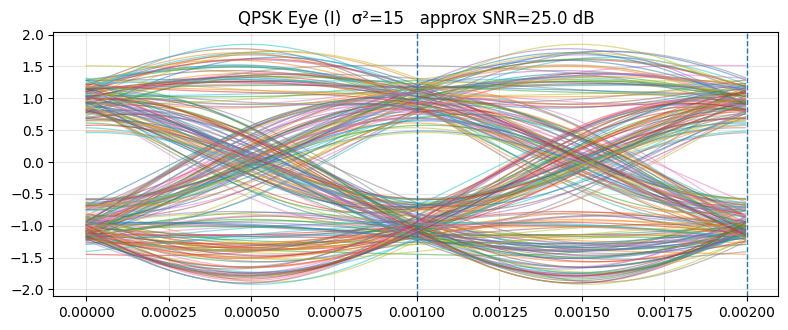

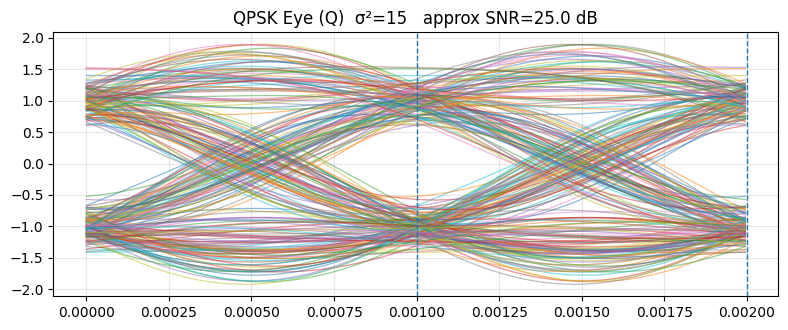

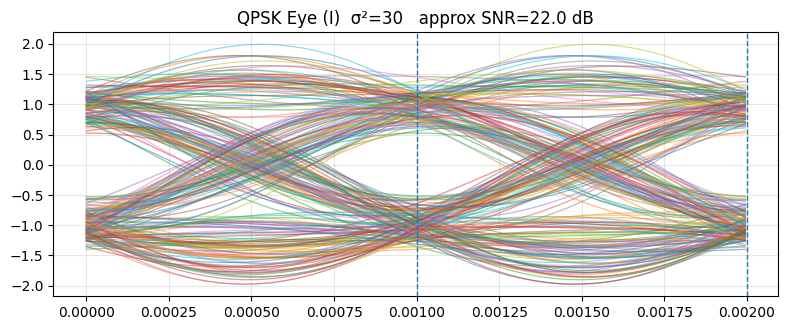

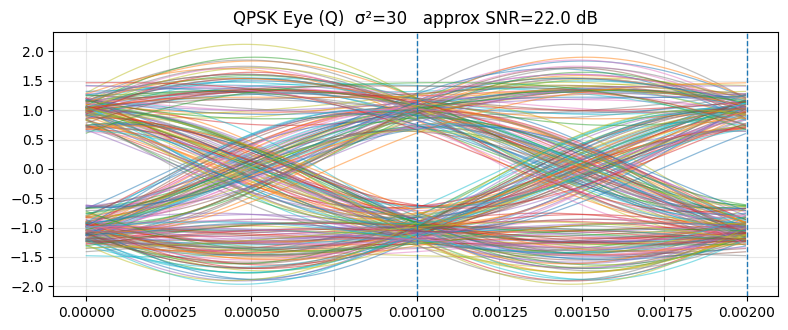

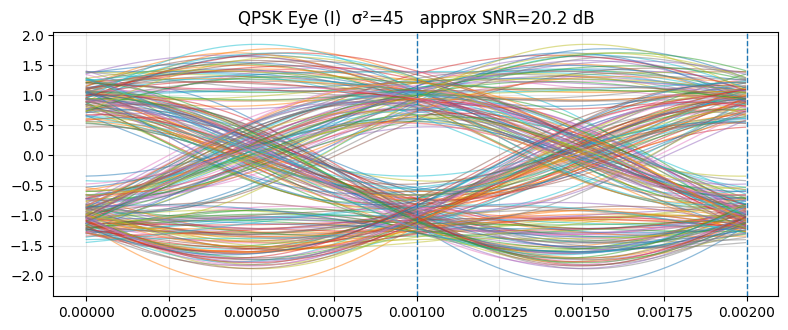

...

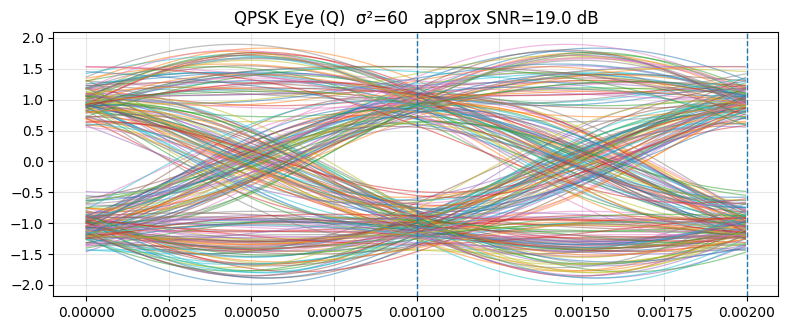

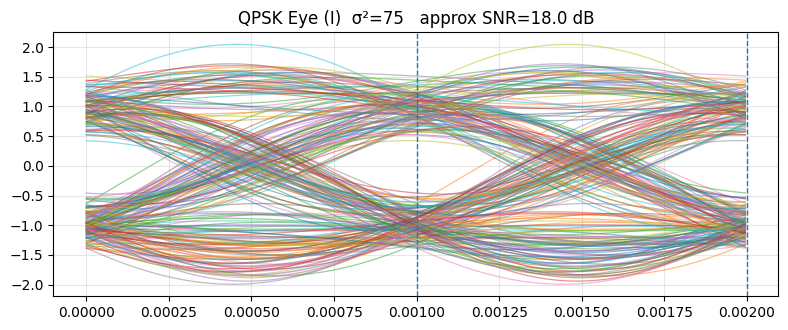

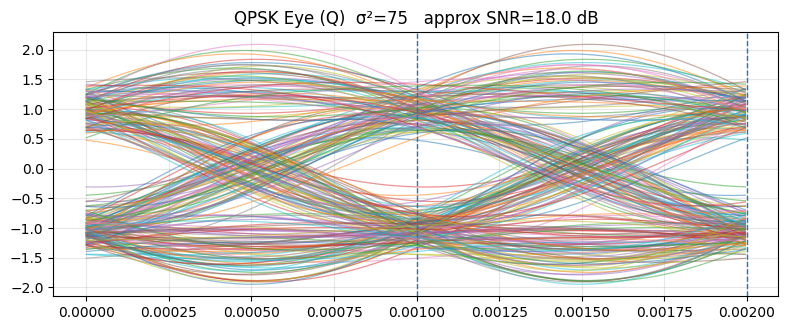

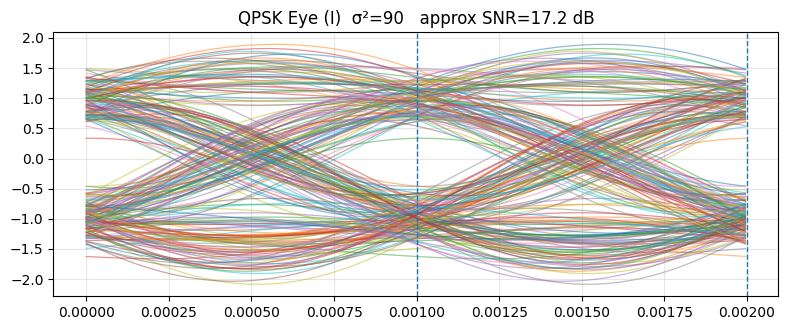

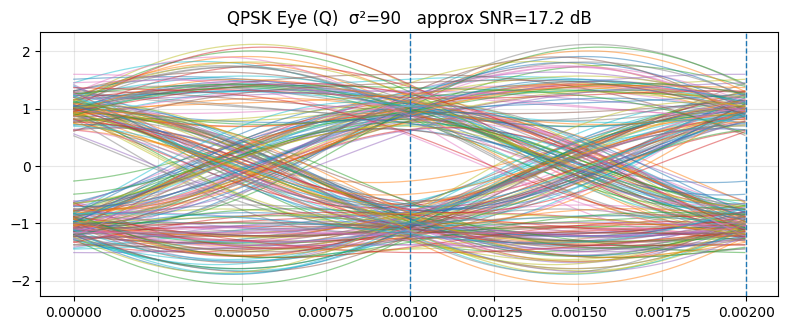

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def raised_cosine_pulse(beta, Tb, fs, span_symbols=8):
    Ts = 1 / fs
    N = int(span_symbols * Tb * fs)
    if N % 2 == 0:
        N += 1
    t = (np.arange(N) - N // 2) * Ts
    p = np.zeros_like(t)
    for i, ti in enumerate(t):
        x = ti / Tb
        if np.isclose(ti, 0.0):
            p[i] = 1.0
        elif beta != 0 and np.isclose(abs(x), 1 / (2 * beta)):
            p[i] = (np.pi / 4) * np.sinc(1 / (2 * beta))
        else:
            p[i] = np.sinc(x) * np.cos(np.pi * beta * x) / (1 - (2 * beta * x) ** 2)
    p /= (np.sqrt(np.sum(p**2)) + 1e-15)
    return p

def synthesize_y(symbols, p, sps):
    up = np.zeros(len(symbols) * sps)
    up[::sps] = symbols
    return np.convolve(up, p, mode="same")

def eye_segments(y, sps, window_symbols=2, max_traces=250, skip_symbols=10, offset=0):
    L = window_symbols * sps
    start = skip_symbols * sps + offset
    end = len(y) - L - skip_symbols * sps
    if end <= start:
        return None
    starts = np.arange(start, end + 1, sps)
    if len(starts) > max_traces:
        starts = starts[:max_traces]
    return np.stack([y[i:i+L] for i in starts], axis=0)

def plot_eye(y, Tb, fs, sps, title, offset=0):
    segs = eye_segments(y, sps, window_symbols=2, max_traces=250, skip_symbols=10, offset=offset)
    if segs is None:
        print("too short")
        return
    t = np.arange(segs.shape[1]) / fs
    plt.figure(figsize=(8, 3.4))
    for s in segs:
        plt.plot(t, s, alpha=0.5, linewidth=0.9)
    plt.axvline(Tb, linestyle="--", linewidth=1.0)
    plt.axvline(2*Tb, linestyle="--", linewidth=1.0)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


Tb = 1e-3
fs = 200_000
sps = int(round(Tb * fs))

beta = 0.35
p = raised_cosine_pulse(beta, Tb, fs, span_symbols=10)
gd = (len(p) - 1) // 2

Nsym = 600
I = np.random.choice([-1, 1], size=Nsym)
Q = np.random.choice([-1, 1], size=Nsym)

yI_tx = synthesize_y(I, p, sps)
yQ_tx = synthesize_y(Q, p, sps)

zI_tx = np.convolve(yI_tx, p[::-1], mode="same")
zQ_tx = np.convolve(yQ_tx, p[::-1], mode="same")

Ps = 0.5 * (np.mean(zI_tx**2) + np.mean(zQ_tx**2))

sigma2_list = [15, 30, 45, 60, 75, 90]
sigma2_ref = 15
SNR_ref_dB = 25
SNR_ref = 10 ** (SNR_ref_dB / 10)
k = Ps / (SNR_ref * sigma2_ref)

np.random.seed(1)

for sigma2 in sigma2_list:
    noise_var = k * sigma2
    yI_rx = yI_tx + np.sqrt(noise_var) * np.random.randn(len(yI_tx))
    yQ_rx = yQ_tx + np.sqrt(noise_var) * np.random.randn(len(yQ_tx))

    zI = np.convolve(yI_rx, p[::-1], mode="same")
    zQ = np.convolve(yQ_rx, p[::-1], mode="same")

    snr_lin = Ps / (noise_var + 1e-15)
    snr_db = 10 * np.log10(snr_lin + 1e-15)

    plot_eye(zI, Tb, fs, sps, title=f"QPSK Eye (I)  σ²={sigma2}   approx SNR={snr_db:.1f} dB", offset=gd)
    plot_eye(zQ, Tb, fs, sps, title=f"QPSK Eye (Q)  σ²={sigma2}   approx SNR={snr_db:.1f} dB", offset=gd)
    # save
    MOD_NAME = "QPSK"
saved = globals().get("saved", {})
saved.setdefault("EYE", {})
saved["EYE"][MOD_NAME] = {
    "sigma2_list": sigma2_list if "sigma2_list" in globals() else None,
    "Tb": Tb if "Tb" in globals() else None,
    "fs": fs if "fs" in globals() else None,
}
globals()["saved"] = saved



16QAM :

a )

In [25]:

L = 8000
SEED = 6

symbol_probs = {
    "A": 0.25,
    "B": 0.20,
    "C": 0.15,
    "D": 0.10,
    "E": 0.08,
    "F": 0.07,
    "G": 0.05,
    "H": 0.04,
    "I": 0.04,
    "J": 0.02,
}

# 1) generate symbols strictly from Table 1
msg = generate_data(symbol_probs, length=L, seed=SEED)

print("16-QAM Part (a) — Generation rule:")
print("random.seed(SEED)")
print("random.choices(Table1 alphabet, weights, k=L)")
print("L =", L, "SEED =", SEED)
print("first 80 symbols:", msg[:80])

# 2) source coding (Huffman)
codebook = huffman_code(symbol_probs)
bits_src = source_coder(msg, codebook)

# 3) channel coding (Hamming 7,4)
bits_ham = hamming_coder(bits_src, pad=True)

print("\nLengths:")
print("symbols:", len(msg))
print("source-coded bits:", len(bits_src))
print("hamming-coded bits:", len(bits_ham))

pad_bits = (4 - (len(bits_src) % 4)) % 4
print("zero padding before Hamming:", pad_bits)

# bits_ham is the final 0/1 bitstream used for 16-QAM (4-bit groups) in Part (b)




#saving the block
MOD_NAME = "16QAM"
saved = globals().get("saved", {})
saved["symbol_probs"] = symbol_probs
saved["L"] = L
saved["SEED"] = SEED
saved["msg"] = msg
saved["bits_src"] = bits_src
saved["bits_ham"] = bits_ham
saved["bitstream_all"] = bits_ham.strip().replace(" ", "")
globals()["saved"] = saved


16-QAM Part (a) — Generation rule:
random.seed(SEED)
random.choices(Table1 alphabet, weights, k=L)
L = 8000 SEED = 6
first 80 symbols: FFCBADCEBEBFEBCDACFBFDFBAFFBAADBICADBHHCDDFIABDBCAGCADBACAAGDAEABHDBBBAJABEBJAIG

Lengths:
symbols: 8000
source-coded bits: 23955
hamming-coded bits: 41923
zero padding before Hamming: 1


b )

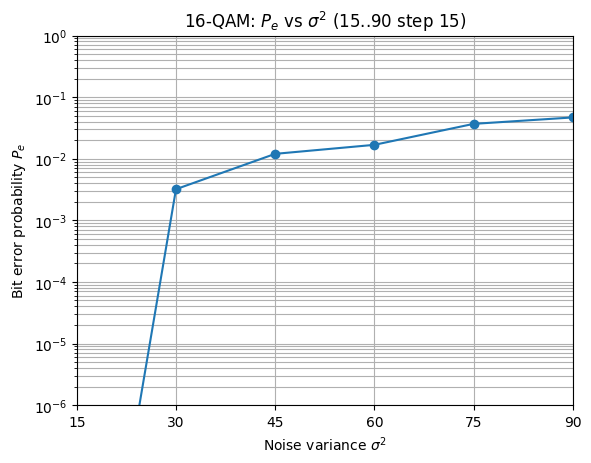

N bits: 2500 N symbols: 625
A used: 0.21544346900318834 (cal BER ~ 0.0152 )
var_list: [15. 30. 45. 60. 75. 90.]
Pe: [0.     0.0032 0.012  0.0168 0.0368 0.0468]


In [46]:

import numpy as np
import matplotlib.pyplot as plt

fs = 1e6
Tb = 10e-3
fc = 10e3
Ns = int(round(fs * Tb))

def channel_ideal(x, length_km=0.83, att_db_per_km=0.2):
    gain = 10 ** (-(att_db_per_km * float(length_km)) / 20.0)
    return gain * np.asarray(x)

N_BITS_SIM = 2500
bitstream = bits_ham.strip().replace(" ", "")[:N_BITS_SIM]
if len(bitstream) < 40:
    raise ValueError("bitstream too short")

def bits_to_symbols_4bit(bits01: str):
    if any(c not in "01" for c in bits01):
        raise ValueError("bitstream must contain only 0/1")
    if len(bits01) % 4 != 0:
        bits01 += "0" * (4 - (len(bits01) % 4))
    syms = [int(bits01[i:i+4], 2) for i in range(0, len(bits01), 4)]
    return np.array(syms, dtype=int), bits01

def symbols_to_bits_4bit(syms):
    return "".join(f"{int(s) & 0xF:04b}" for s in syms)

syms_tx, bits_used = bits_to_symbols_4bit(bitstream)

gray2_to_level = {0b00: -3.0, 0b01: -1.0, 0b11: +1.0, 0b10: +3.0}
level_to_gray2 = {v: k for k, v in gray2_to_level.items()}
levels = np.array([-3.0, -1.0, +1.0, +3.0])

def sym16_to_IQ(m):
    b = f"{int(m):04b}"
    bI = int(b[0:2], 2)
    bQ = int(b[2:4], 2)
    return gray2_to_level[bI], gray2_to_level[bQ]

I_seq = np.array([sym16_to_IQ(m)[0] for m in syms_tx], dtype=float)
Q_seq = np.array([sym16_to_IQ(m)[1] for m in syms_tx], dtype=float)

t_sym = np.arange(Ns) / fs
c = np.cos(2 * np.pi * fc * t_sym)
s = np.sin(2 * np.pi * fc * t_sym)
c0 = c / np.sqrt(np.sum(c**2))
s0 = s / np.sqrt(np.sum(s**2))

refs = []
for m in range(16):
    I, Q = sym16_to_IQ(m)
    refs.append(I * c - Q * s)

pulse_map_16 = {m: refs[m] for m in range(16)}
t_tx, s_tx = PulseShaping(syms_tx, pulse_map_16, fs=fs, Tb=Tb)
s_tx = np.real(s_tx)

def slicer_4pam(x):
    idx = np.argmin((x[:, None] - levels[None, :])**2, axis=1)
    return levels[idx]

def detect_16qam(r_c, pilot=120):
    K = len(r_c) // Ns
    r = r_c[:K * Ns].reshape(K, Ns)

    Iproj = r @ c0
    Qproj = -(r @ s0)

    P = min(pilot, K)
    denom = (I_seq[:P] @ I_seq[:P]) + (Q_seq[:P] @ Q_seq[:P]) + 1e-12
    alpha = (I_seq[:P] @ Iproj[:P] + Q_seq[:P] @ Qproj[:P]) / denom

    I_hat = Iproj / (alpha + 1e-12)
    Q_hat = Qproj / (alpha + 1e-12)

    I_s = slicer_4pam(I_hat)
    Q_s = slicer_4pam(Q_hat)

    bI = np.array([level_to_gray2[v] for v in I_s], dtype=int)
    bQ = np.array([level_to_gray2[v] for v in Q_s], dtype=int)
    return ((bI << 2) | bQ).astype(int)

rng_cal = np.random.default_rng(1)
length_km = 2
sigma2_cal = 45.0

def ber_for_A(A):
    x = channel_ideal(A * s_tx, length_km=length_km, att_db_per_km=0.2)
    r = add_awgn(x, noise_var=sigma2_cal, rng=rng_cal)
    syms_hat = detect_16qam(r)
    bits_hat = symbols_to_bits_4bit(syms_hat)
    N = min(len(bits_used), len(bits_hat))
    err = sum(bits_used[i] != bits_hat[i] for i in range(N))
    return err / N

A_candidates = np.logspace(-2, 2, 25)
target = 5e-3

best_A = A_candidates[0]
best_diff = float("inf")
best_ber = None
for A_try in A_candidates:
    ber = ber_for_A(A_try)
    diff = abs(np.log10(ber + 1e-12) - np.log10(target))
    if diff < best_diff:
        best_diff = diff
        best_A = A_try
        best_ber = ber

A = best_A

var_list = np.arange(15, 91, 15, dtype=float)
Pe = []
rng = np.random.default_rng(0)

for var in var_list:
    x_ch = channel_ideal(A * s_tx, length_km=length_km, att_db_per_km=0.2)
    r_c = add_awgn(x_ch, noise_var=var, rng=rng)

    syms_hat = detect_16qam(r_c)
    bits_hat = symbols_to_bits_4bit(syms_hat)

    N = min(len(bits_used), len(bits_hat))
    err = sum(bits_used[i] != bits_hat[i] for i in range(N))
    Pe.append(err / N)

Pe = np.array(Pe)
Pe_plot = np.where(Pe == 0, 1e-12, Pe)

plt.figure()
plt.semilogy(var_list, Pe_plot, marker="o")
plt.xticks(var_list)
plt.xlabel(r"Noise variance $\sigma^2$")
plt.ylabel(r"Bit error probability $P_e$")
plt.grid(True, which="both")
plt.title(r"16-QAM: $P_e$ vs $\sigma^2$ (15..90 step 15)")
plt.ylim(1e-6, 1)
plt.xlim(15, 90)
plt.show()

print("var_list:", var_list)
print("Pe:", Pe)

#saving the block
MOD_NAME = "16QAM"
saved = globals().get("saved", {})
saved.setdefault("BER", {})
saved["BER"].setdefault(MOD_NAME, {})

L = float(length_km)

saved["BER"][MOD_NAME][L] = {
    "A": A,
    "var_list": np.array(var_list, dtype=float),
    "Pe": np.array(Pe, dtype=float),
}

for k in list(saved["BER"][MOD_NAME].keys()):
    if not isinstance(k, float):
        del saved["BER"][MOD_NAME][k]

globals()["saved"] = saved







c )

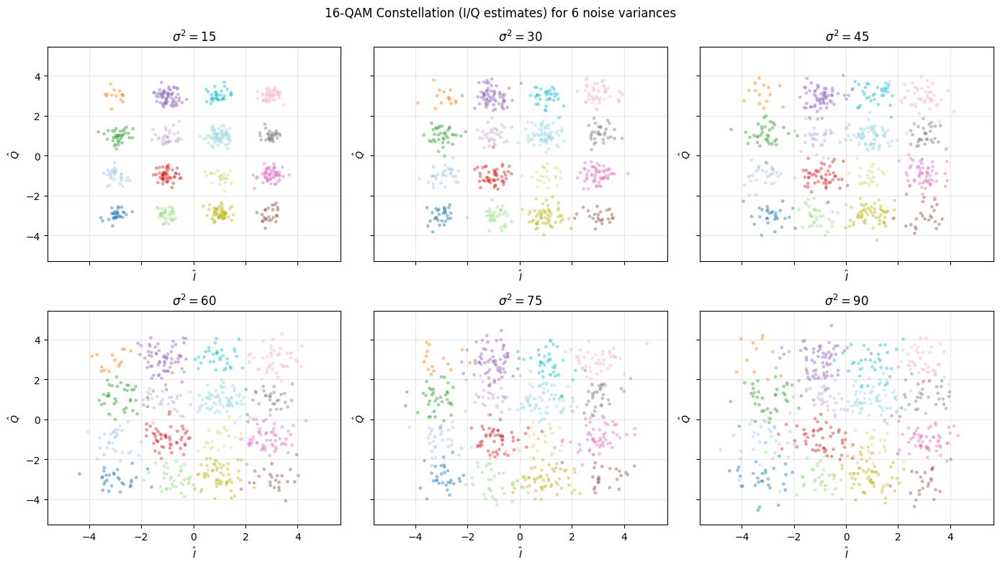

In [27]:

def iq_scores_16qam(r_c, c0, s0, I_seq, Q_seq, Ns, alpha_use=None, pilot=120):
    K = len(r_c) // Ns
    r = r_c[:K * Ns].reshape(K, Ns)

    Iproj = r @ c0
    Qproj = -(r @ s0)

    if alpha_use is None:
        P = min(pilot, K)
        denom = (I_seq[:P] @ I_seq[:P]) + (Q_seq[:P] @ Q_seq[:P]) + 1e-12
        alpha = (I_seq[:P] @ Iproj[:P] + Q_seq[:P] @ Qproj[:P]) / denom
    else:
        alpha = float(alpha_use)

    I_hat = Iproj / (alpha + 1e-12)
    Q_hat = Qproj / (alpha + 1e-12)
    return I_hat, Q_hat, K, alpha


var_ref = float(var_list[0])
x_ch_ref = channel_ideal(A * s_tx, length_km=length_km, att_db_per_km=0.2)
r_ref = add_awgn(x_ch_ref, noise_var=var_ref, rng=np.random.default_rng(123))

I_ref, Q_ref, K_ref, alpha_ref = iq_scores_16qam(
    r_ref, c0, s0, I_seq, Q_seq, Ns, alpha_use=None, pilot=120
)

iq_by_var = []
all_iq = []

for var in var_list:
    x_ch = channel_ideal(A * s_tx, length_km=length_km, att_db_per_km=0.2)
    r_c = add_awgn(x_ch, noise_var=float(var), rng=np.random.default_rng(1000 + int(var)))

    I_hat, Q_hat, K, _ = iq_scores_16qam(
        r_c, c0, s0, I_seq, Q_seq, Ns, alpha_use=alpha_ref, pilot=120
    )

    tx_syms = syms_tx[:K]
    iq = np.column_stack([I_hat, Q_hat])
    iq_by_var.append((var, iq, tx_syms))
    all_iq.append(iq)

all_iq = np.vstack(all_iq)
xmin, ymin = all_iq.min(axis=0)
xmax, ymax = all_iq.max(axis=0)

mx = 0.08 * (xmax - xmin + 1e-12)
my = 0.08 * (ymax - ymin + 1e-12)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (var, iq, tx_syms) in zip(axes, iq_by_var):
    ax.scatter(iq[:, 0], iq[:, 1], s=6, alpha=0.35, c=tx_syms, cmap="tab20")
    ax.set_title(rf"$\sigma^2={var:.0f}$")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(xmin - mx, xmax + mx)
    ax.set_ylim(ymin - my, ymax + my)
    ax.set_xlabel(r"$\hat{I}$")
    ax.set_ylabel(r"$\hat{Q}$")

fig.suptitle("16-QAM Constellation (I/Q estimates) for 6 noise variances", y=0.98)
plt.tight_layout()
plt.show()

#save
MOD_NAME = "16QAM"
saved = globals().get("saved", {})
saved.setdefault("SCATTER", {})
saved["SCATTER"][MOD_NAME] = proj_by_var
globals()["saved"] = saved


d )

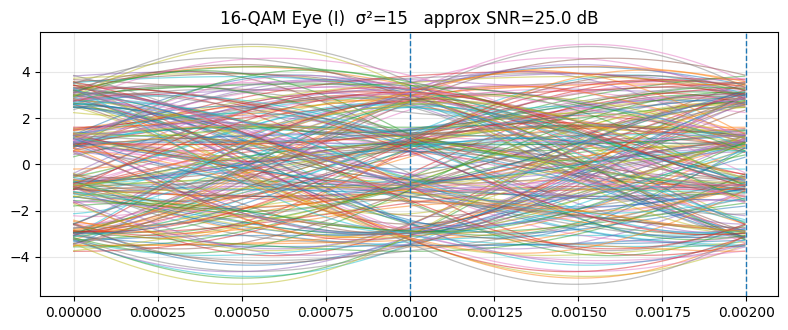

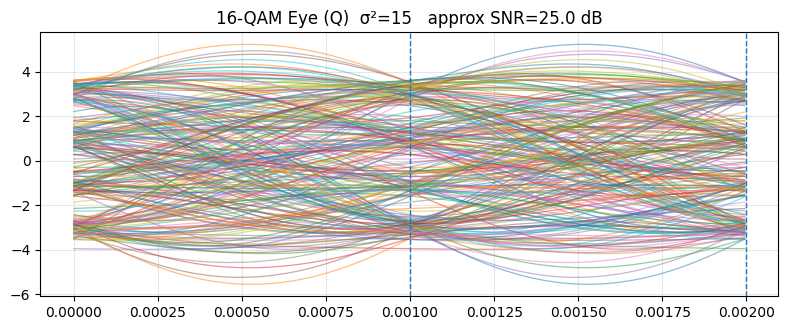

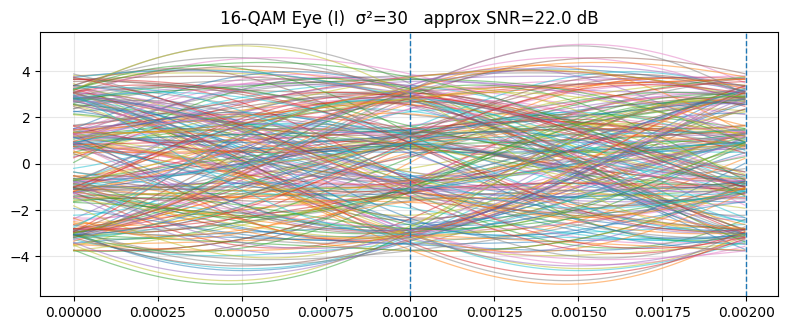

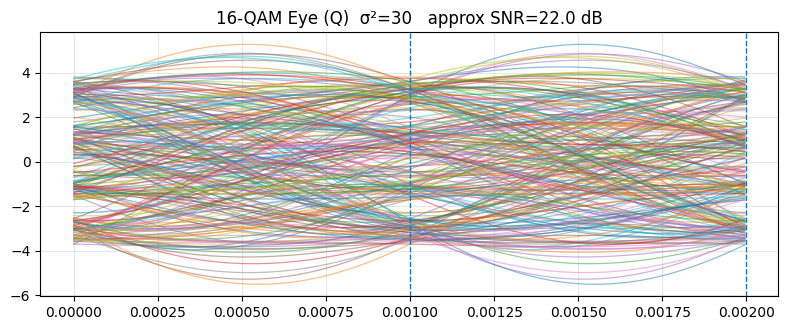

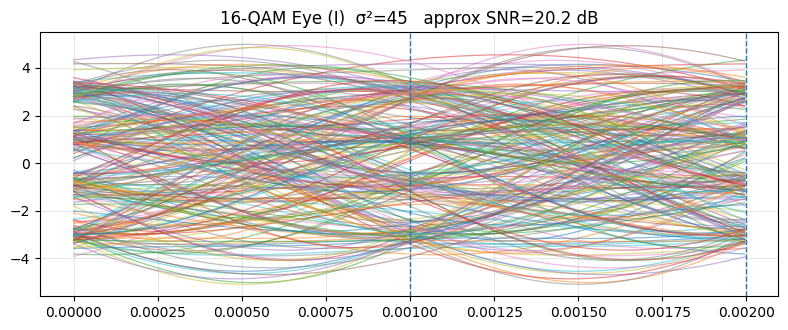

...

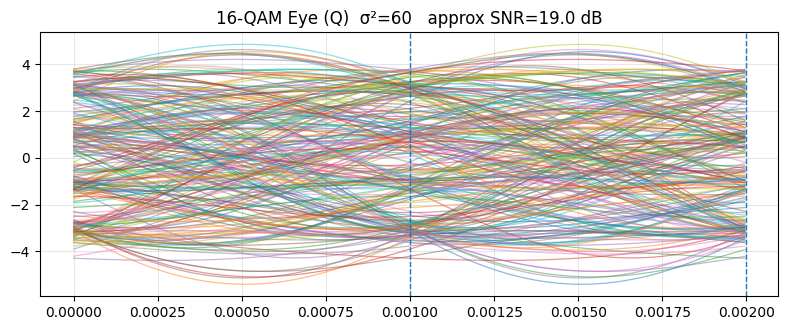

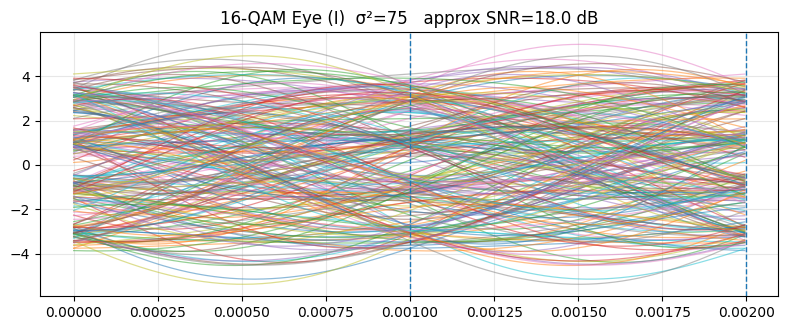

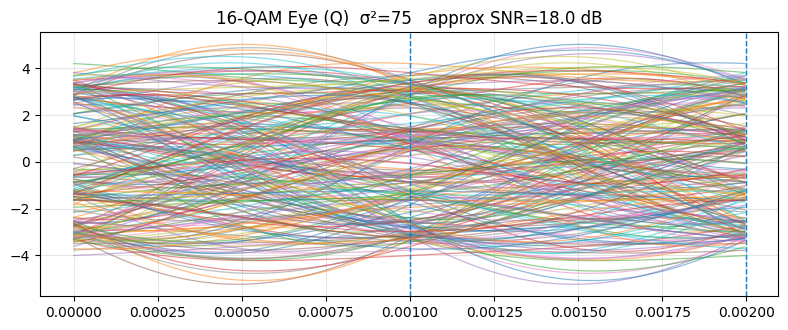

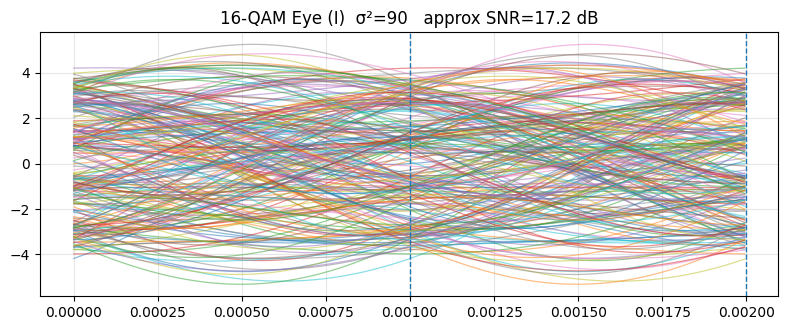

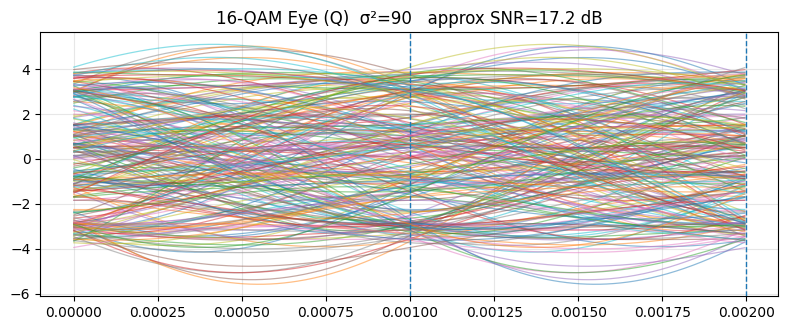

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def raised_cosine_pulse(beta, Tb, fs, span_symbols=8):
    Ts = 1 / fs
    N = int(span_symbols * Tb * fs)
    if N % 2 == 0:
        N += 1
    t = (np.arange(N) - N // 2) * Ts
    p = np.zeros_like(t)
    for i, ti in enumerate(t):
        x = ti / Tb
        if np.isclose(ti, 0.0):
            p[i] = 1.0
        elif beta != 0 and np.isclose(abs(x), 1 / (2 * beta)):
            p[i] = (np.pi / 4) * np.sinc(1 / (2 * beta))
        else:
            p[i] = np.sinc(x) * np.cos(np.pi * beta * x) / (1 - (2 * beta * x) ** 2)
    p /= (np.sqrt(np.sum(p**2)) + 1e-15)
    return p

def synthesize_y(symbols, p, sps):
    up = np.zeros(len(symbols) * sps)
    up[::sps] = symbols
    return np.convolve(up, p, mode="same")

def eye_segments(y, sps, window_symbols=2, max_traces=250, skip_symbols=10, offset=0):
    L = window_symbols * sps
    start = skip_symbols * sps + offset
    end = len(y) - L - skip_symbols * sps
    if end <= start:
        return None
    starts = np.arange(start, end + 1, sps)
    if len(starts) > max_traces:
        starts = starts[:max_traces]
    return np.stack([y[i:i+L] for i in starts], axis=0)

def plot_eye(y, Tb, fs, sps, title, offset=0):
    segs = eye_segments(y, sps, window_symbols=2, max_traces=250, skip_symbols=10, offset=offset)
    if segs is None:
        print("too short")
        return
    t = np.arange(segs.shape[1]) / fs
    plt.figure(figsize=(8, 3.4))
    for s in segs:
        plt.plot(t, s, alpha=0.5, linewidth=0.9)
    plt.axvline(Tb, linestyle="--", linewidth=1.0)
    plt.axvline(2*Tb, linestyle="--", linewidth=1.0)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


Tb = 1e-3
fs = 200_000
sps = int(round(Tb * fs))

beta = 0.35
p = raised_cosine_pulse(beta, Tb, fs, span_symbols=10)
gd = (len(p) - 1) // 2

Nsym = 600
levels = np.array([-3, -1, 1, 3], dtype=float)
I = np.random.choice(levels, size=Nsym)
Q = np.random.choice(levels, size=Nsym)

yI_tx = synthesize_y(I, p, sps)
yQ_tx = synthesize_y(Q, p, sps)

zI_tx = np.convolve(yI_tx, p[::-1], mode="same")
zQ_tx = np.convolve(yQ_tx, p[::-1], mode="same")

Ps = 0.5 * (np.mean(zI_tx**2) + np.mean(zQ_tx**2))

sigma2_list = [15, 30, 45, 60, 75, 90]
sigma2_ref = 15
SNR_ref_dB = 25
SNR_ref = 10 ** (SNR_ref_dB / 10)
k = Ps / (SNR_ref * sigma2_ref)

np.random.seed(1)

for sigma2 in sigma2_list:
    noise_var = k * sigma2
    yI_rx = yI_tx + np.sqrt(noise_var) * np.random.randn(len(yI_tx))
    yQ_rx = yQ_tx + np.sqrt(noise_var) * np.random.randn(len(yQ_tx))

    zI = np.convolve(yI_rx, p[::-1], mode="same")
    zQ = np.convolve(yQ_rx, p[::-1], mode="same")

    snr_lin = Ps / (noise_var + 1e-15)
    snr_db = 10 * np.log10(snr_lin + 1e-15)

    plot_eye(zI, Tb, fs, sps, title=f"16-QAM Eye (I)  σ²={sigma2}   approx SNR={snr_db:.1f} dB", offset=gd)
    plot_eye(zQ, Tb, fs, sps, title=f"16-QAM Eye (Q)  σ²={sigma2}   approx SNR={snr_db:.1f} dB", offset=gd)

    #save
    MOD_NAME = "16QAM"
saved = globals().get("saved", {})
saved.setdefault("EYE", {})
saved["EYE"][MOD_NAME] = {
    "sigma2_list": sigma2_list if "sigma2_list" in globals() else None,
    "Tb": Tb if "Tb" in globals() else None,
    "fs": fs if "fs" in globals() else None,
}
globals()["saved"] = saved



 3.1:

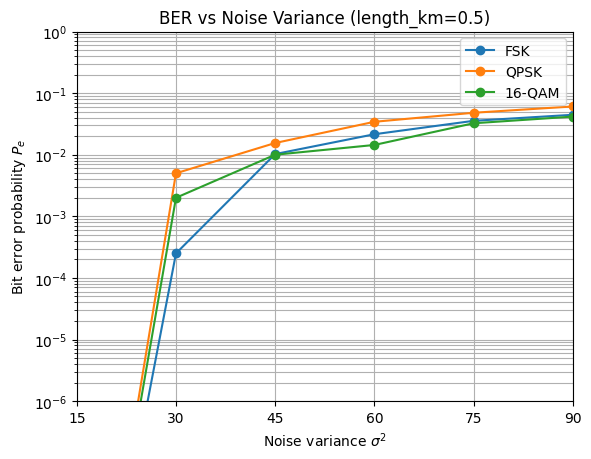

sigma2 : [15 30 45 60 75 90]
FSK   : [0.      0.00025 0.01025 0.0215  0.0355  0.0445 ]
QPSK  : [0.      0.005   0.0155  0.03425 0.048   0.06075]
16QAM : [0.     0.002  0.01   0.0144 0.0324 0.0416]
Best  : ['FSK', 'FSK', '16-QAM', '16-QAM', '16-QAM', '16-QAM']

At sigma^2 = 60:
FSK   : 0.0215
QPSK  : 0.03425
16QAM : 0.0144
Best  : 16-QAM


In [40]:
import numpy as np
import matplotlib.pyplot as plt

BER = saved["BER"]

for k in ["FSK", "QPSK", "16QAM"]:
    if k not in BER:
        raise ValueError(f"Missing BER for {k}. Run its Part (b) with MOD_NAME='{k}' and saving snippet.")

v_fsk  = BER["FSK"]["var_list"]
v_qpsk = BER["QPSK"]["var_list"]
v_16   = BER["16QAM"]["var_list"]

if not (np.allclose(v_fsk, v_qpsk) and np.allclose(v_fsk, v_16)):
    raise ValueError("var_list mismatch across modulations. Make them identical and rerun (b).")

var_list = v_fsk

Pe_fsk  = np.array(BER["FSK"]["Pe"], dtype=float)
Pe_qpsk = np.array(BER["QPSK"]["Pe"], dtype=float)
Pe_16   = np.array(BER["16QAM"]["Pe"], dtype=float)

Pe_fsk_p  = np.where(Pe_fsk  == 0, 1e-12, Pe_fsk)
Pe_qpsk_p = np.where(Pe_qpsk == 0, 1e-12, Pe_qpsk)
Pe_16_p   = np.where(Pe_16   == 0, 1e-12, Pe_16)

plt.figure()
plt.semilogy(var_list, Pe_fsk_p,  marker="o", label="FSK")
plt.semilogy(var_list, Pe_qpsk_p, marker="o", label="QPSK")
plt.semilogy(var_list, Pe_16_p,   marker="o", label="16-QAM")
plt.xticks(var_list)
plt.xlabel(r"Noise variance $\sigma^2$")
plt.ylabel(r"Bit error probability $P_e$")
plt.grid(True, which="both")
plt.title(f"BER vs Noise Variance (length_km={BER['FSK']['length_km']})")
plt.ylim(1e-6, 1)
plt.xlim(float(var_list.min()), float(var_list.max()))
plt.legend()
plt.show()

stack = np.vstack([Pe_fsk, Pe_qpsk, Pe_16])
names = np.array(["FSK", "QPSK", "16-QAM"])
best_idx = np.argmin(stack, axis=0)
best_name = names[best_idx]

print("sigma2 :", var_list.astype(int))
print("FSK   :", Pe_fsk)
print("QPSK  :", Pe_qpsk)
print("16QAM :", Pe_16)
print("Best  :", best_name.tolist())

if 60 in var_list:
    i = int(np.where(var_list == 60)[0][0])
    print("\nAt sigma^2 = 60:")
    print("FSK   :", Pe_fsk[i])
    print("QPSK  :", Pe_qpsk[i])
    print("16QAM :", Pe_16[i])
    print("Best  :", best_name[i])


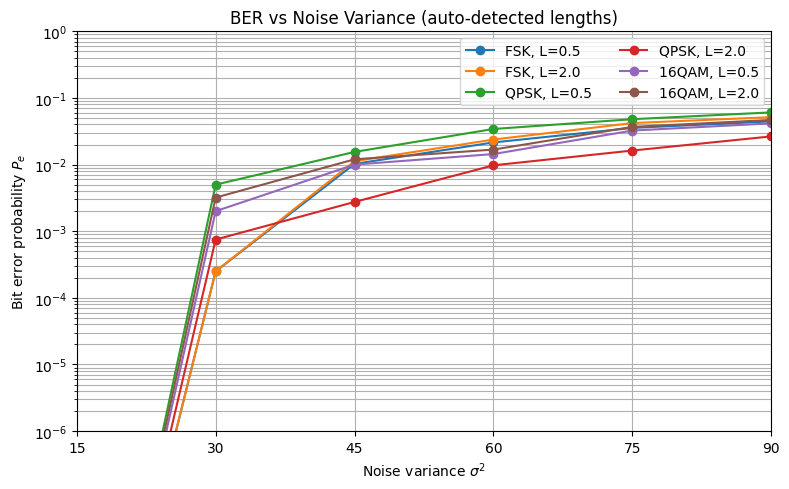

In [47]:
import numpy as np
import matplotlib.pyplot as plt

mods = ["FSK", "QPSK", "16QAM"]

lengths = sorted(saved["BER"]["FSK"].keys())

var_list = saved["BER"]["FSK"][lengths[0]]["var_list"]

plt.figure(figsize=(8, 5))

for m in mods:
    for L in lengths:
        Pe = saved["BER"][m][L]["Pe"]
        Pe = np.where(Pe == 0, 1e-12, Pe)
        plt.semilogy(
            var_list,
            Pe,
            marker="o",
            label=f"{m}, L={L}"
        )

plt.xticks(var_list)
plt.xlabel(r"Noise variance $\sigma^2$")
plt.ylabel(r"Bit error probability $P_e$")
plt.grid(True, which="both")
plt.ylim(1e-6, 1)
plt.xlim(float(var_list.min()), float(var_list.max()))
plt.title("BER vs Noise Variance (auto-detected lengths)")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()
